## basic chatbot

In [8]:
from dotenv import load_dotenv

load_dotenv()

True

In [ ]:
from langchain.chat_models import init_chat_model 
from langgraph.graph import StateGraph, START, END, add_messages
from typing_extensions import TypedDict, Annotated, Literal

# initialize llm model
llm = init_chat_model(
    model = "google_genai:gemini-2.5-flash-lite"
)


# state
class State(TypedDict):
    messages: Annotated[list, add_messages] #reducer function which preserves human message as well


# node definition
def chatbot(state: State) -> State:
    return {"messages": [llm.invoke(state["messages"])]}


# build graph
builder = StateGraph(State)

# add nodes
builder.add_node("chatbot_node", chatbot)

# add edges
builder.add_edge(START, "chatbot_node")
builder.add_edge("chatbot_node", END)

graph = builder.compile()

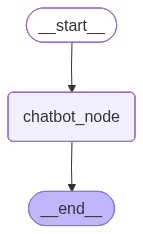

In [10]:
from IPython.display import Image, display 

display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
graph.invoke({"messages": "Founder of NVIDIA and what is the capital of India?"})

{'messages': [HumanMessage(content='Founder of NVIDIA and what is the capital of India?', additional_kwargs={}, response_metadata={}, id='d412c1d6-0d9b-47bb-8485-0270b68c49ad'),
  AIMessage(content='The founder of NVIDIA is **Jensen Huang**.\n\nThe capital of India is **New Delhi**.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ea9fc-7a0f-7020-a65c-576baba76924-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 19, 'total_tokens': 31, 'input_token_details': {'cache_read': 0}})]}

### simple chat loop

- start → initialize state → get user input → append to state → invoke graph → print reply → loop

In [ ]:
state = None  # No conversation started yet

while True:
    in_message = input("You: ")
    if in_message.lower() in {"quit", "exit"}:
        break 
    if state is None:
        state = {
            "messages": [{"role": "user", "content": in_message}]
        }
    else:
        state["messages"].append({"role": "user", "content": in_message})

    state = graph.invoke(state)
    print("Bot: ", state["messages"][-1].content)

Bot:  The founder of NVIDIA is **Jensen Huang**.
Bot:  NVIDIA's market share is a complex and dynamic figure, as it varies significantly depending on the specific market segment you're looking at. However, they are undeniably a dominant player in several key areas.

Here's a breakdown of their market share in prominent sectors:

**1. Discrete Graphics Processing Units (GPUs) for Gaming:**

*   **Dominant Player:** NVIDIA has historically held a very strong and often dominant market share in the discrete GPU market for gaming. While AMD is their main competitor, NVIDIA has consistently led in terms of units shipped and revenue.
*   **Typical Range:** Their market share in this segment has often hovered in the **70-80% range**, sometimes even higher. This is a significant lead over AMD.

**2. Data Center/AI Accelerators (GPUs for AI and High-Performance Computing):**

*   **Near Monopolistic Dominance:** This is where NVIDIA's market share is arguably most impressive and has seen explosi

In [ ]:
# limitations of llm

state = None  # No conversation started yet

while True:
    in_message = input("You: ")
    if in_message.lower() in {"quit", "exit"}:
        break 
    if state is None:
        state = {
            "messages": [{"role": "user", "content": in_message}]
        }
    else:
        state["messages"].append({"role": "user", "content": in_message})

    state = graph.invoke(state)
    print("Bot: ", state["messages"][-1].content)

Bot:  I cannot provide real-time stock prices. My knowledge base is not updated in real-time, and stock prices fluctuate constantly.

To get the latest price of MSFT (Microsoft) stock, you can use any of the following reliable sources:

*   **Financial News Websites:**
    *   Google Finance
    *   Yahoo Finance
    *   Bloomberg
    *   Reuters
    *   The Wall Street Journal

*   **Brokerage Platforms:** If you have a brokerage account, their platform will have real-time stock quotes.

*   **Stock Market Apps:** Many mobile apps provide live stock data.

Just search for "MSFT stock price" on any of these platforms.
